In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score
)
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv("../data/raw/job_salary_prediction_dataset.csv")
data

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [3]:
data.shape

(250000, 10)

In [4]:
data.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


In [6]:
data.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
data.describe(include="object")

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [8]:
data.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.memory_usage(deep=True)

Index                   132
job_title           6061551
experience_years    2000000
education_level     3750430
skills_count        2000000
industry            4174893
company_size        3648620
location            3600551
remote_work         2916807
certifications      2000000
salary              2000000
dtype: int64

In [11]:
categorical_columns = data.select_dtypes(include="object").columns

for column in categorical_columns:
    print("=" * 60)
    print(column)
    print(data[column].value_counts())
    print()

job_title
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

education_level
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

industry
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

company_size
company_size
Large         50254
Small         50235
Medium        50027
Enterpri

In [12]:
data["remote_work"].value_counts()

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

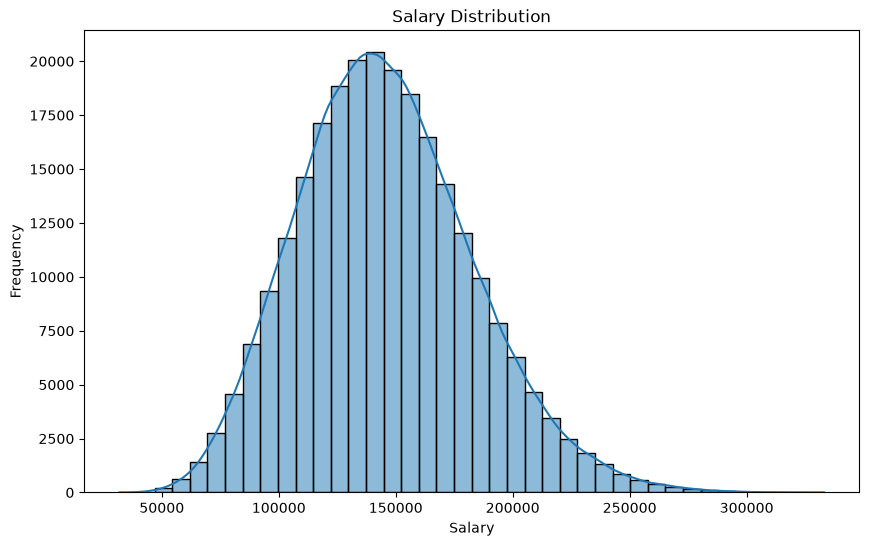

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(data["salary"], bins=40, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

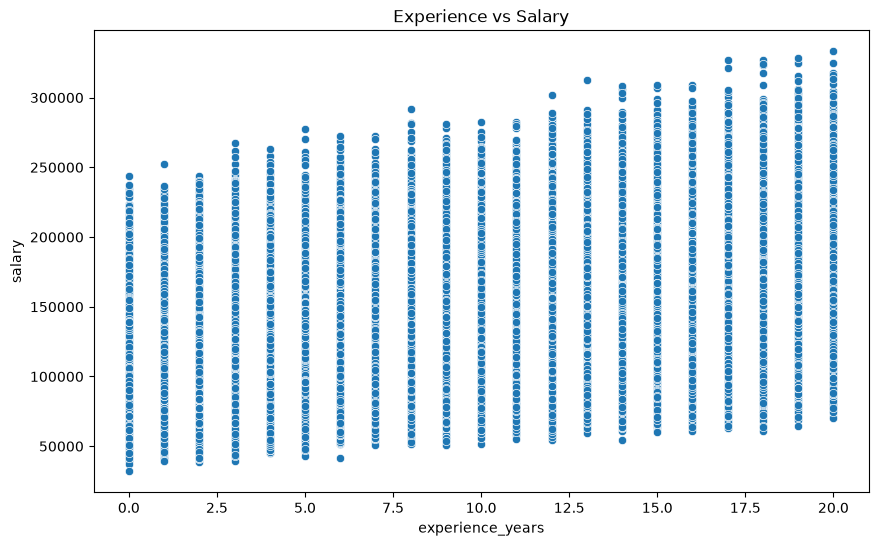

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="experience_years",
    y="salary"
)

plt.title("Experience vs Salary")

plt.show()

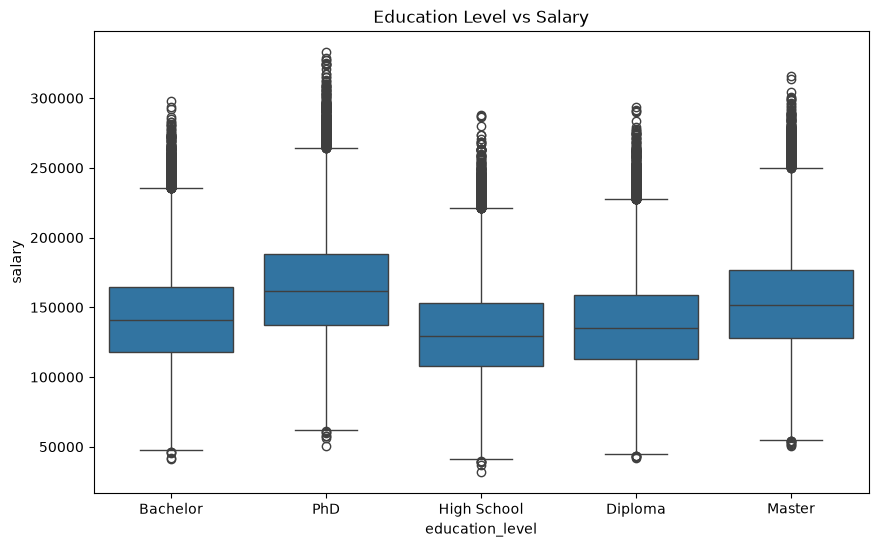

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="education_level",
    y="salary"
)

plt.title("Education Level vs Salary")

plt.show()

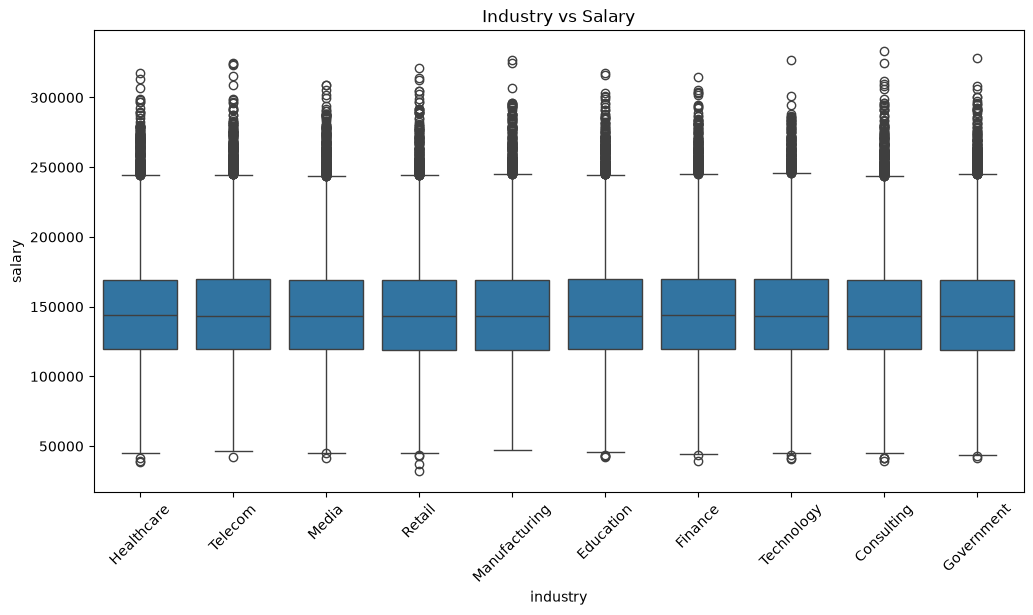

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x="industry",
    y="salary"
)

plt.xticks(rotation=45)

plt.title("Industry vs Salary")

plt.show()

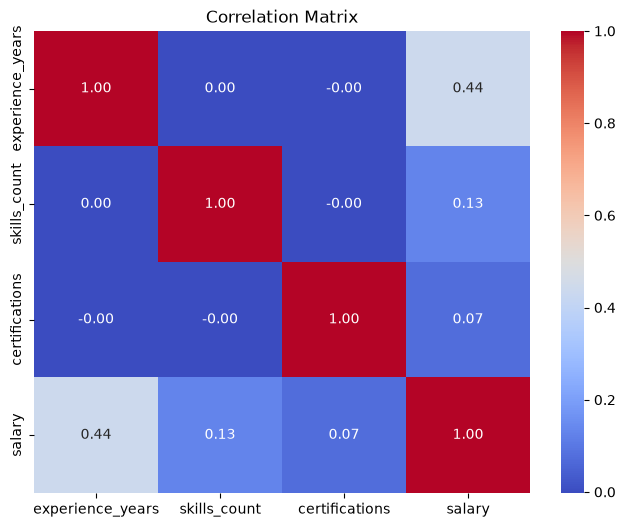

In [17]:
plt.figure(figsize=(8,6))

correlation = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

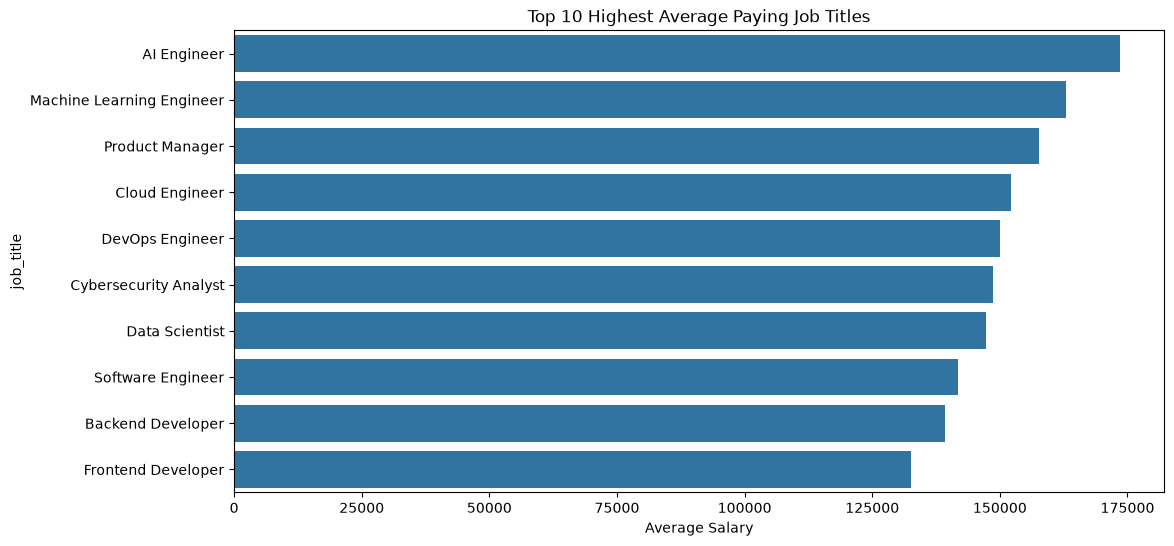

In [18]:
top_jobs = (
    data.groupby("job_title")["salary"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 10 Highest Average Paying Job Titles")
plt.xlabel("Average Salary")

plt.show()

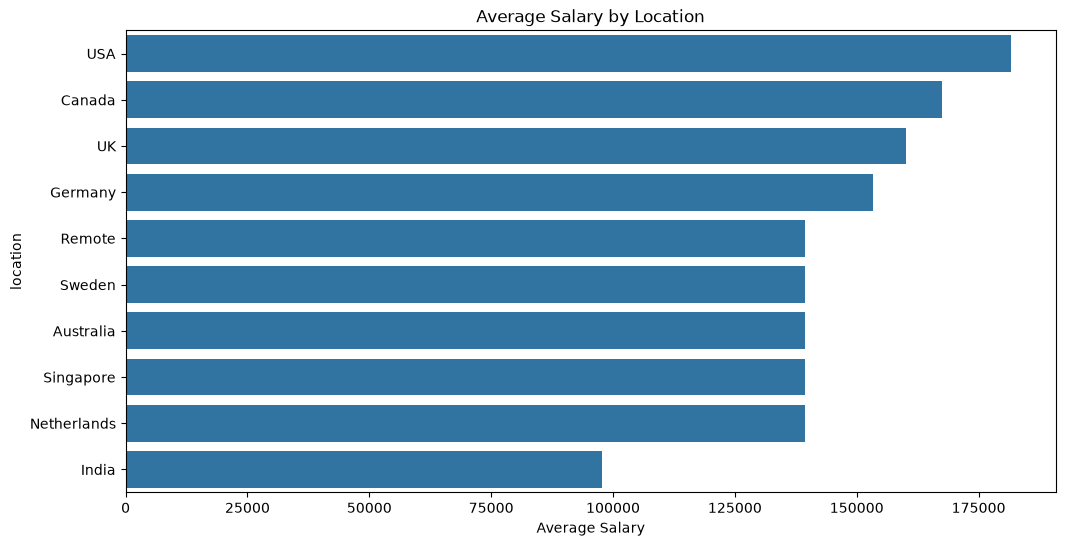

In [19]:
top_locations = (
    data.groupby("location")["salary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Average Salary by Location")
plt.xlabel("Average Salary")

plt.show()

In [20]:
x=data.drop('salary',axis=1)
x

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0
...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5


In [21]:
y=data['salary']
y

0         109413
1          93764
2         148123
3         189123
4         165069
           ...  
249995    127791
249996    154593
249997     75988
249998     90467
249999    133084
Name: salary, Length: 250000, dtype: int64

In [22]:
x_feature=x.select_dtypes(include="object").columns.tolist()
x_feature

['job_title',
 'education_level',
 'industry',
 'company_size',
 'location',
 'remote_work']

In [23]:
y_feature=x.select_dtypes(include=np.number).columns.tolist()
y_feature

['experience_years', 'skills_count', 'certifications']

In [24]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            categorical_transformer,
            x_feature
        )
    ],
    remainder="passthrough"
)

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
model=Pipeline([("preprocessor", preprocessor),
                ('regressor',LinearRegression())])

In [28]:
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['job_title','experience_years','education_level',...,'location', 'remote_work','certifications']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [29]:
model.predict(x_test)

array([172851.16997921,  89234.41298942,  63791.70173227, ...,
       165227.37930178, 151849.60438966, 111755.86827365], shape=(50000,))

In [30]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=30,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )
}

In [31]:
models

{'Linear Regression': LinearRegression(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(n_estimators=30, random_state=42),
 'Extra Trees': ExtraTreesRegressor(n_estimators=30, n_jobs=-1, random_state=42)}

In [32]:
results = []

for name, algorithm in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", algorithm)
    ])

    pipeline.fit(x_train, y_train)

    predictions = pipeline.predict(x_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [33]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
2,Random Forest,5094.731580,6424.418267,0.970304
4,Extra Trees,5236.810504,6591.271078,0.968742
0,Linear Regression,5436.097246,7125.521687,0.963469
1,Decision Tree,7275.753880,9229.436465,0.938712
3,Gradient Boosting,15077.246763,18904.341730,0.742871


#model evaluation

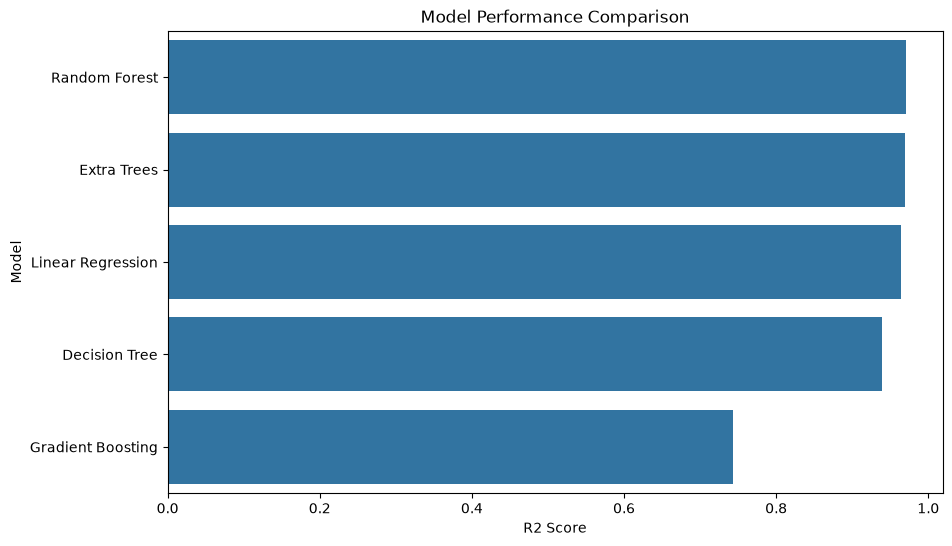

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Model Performance Comparison")

plt.show()

In [43]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ExtraTreesRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", None]
}

In [44]:
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=None,     
    verbose=2
)

search.fit(x_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END regressor__max_depth=10, regressor__max_features=log2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=100; total time=   6.7s
[CV] END regressor__max_depth=10, regressor__max_features=log2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=100; total time=   6.5s
[CV] END regressor__max_depth=10, regressor__max_features=log2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=100; total time=   7.3s
[CV] END regressor__max_depth=10, regressor__max_features=log2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=100; total time=   6.4s
[CV] END regressor__max_depth=10, regressor__max_features=log2, regressor__min_samples_leaf=4, regressor__min_samples_split=10, regressor__n_estimators=100; total time=   6.4s
[CV] END regressor__max_depth=10, regressor__max_features=l

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best est

In [45]:
best_model = search.best_estimator_

print(search.best_params_)
print(search.best_score_)

{'regressor__n_estimators': 200, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_features': None, 'regressor__max_depth': 20}
0.9632769904723453


In [46]:
pred = best_model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 5615.720509711175
RMSE: 7069.5102722805805
R2: 0.9640410941961312


In [47]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_model.named_steps[
    "regressor"
].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
45,remainder__experience_years,0.198775
35,cat__location_India,0.187546
27,cat__company_size_Enterprise,0.107309
41,cat__location_USA,0.078892
16,cat__education_level_PhD,0.062661
0,cat__job_title_AI Engineer,0.053638
28,cat__company_size_Large,0.051239
5,cat__job_title_Data Analyst,0.037806
2,cat__job_title_Business Analyst,0.036648
33,cat__location_Canada,0.035387


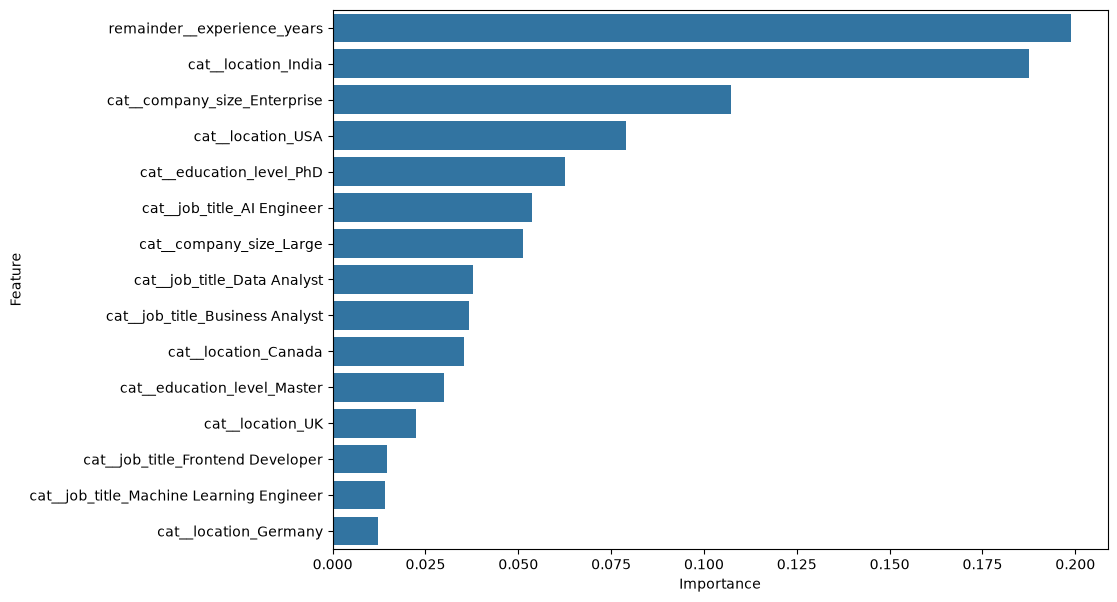

In [48]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.show()

In [49]:
import joblib

joblib.dump(
    best_model,
    "../models/salary_prediction_pipeline.pkl"
)

['../models/salary_prediction_pipeline.pkl']

In [50]:
loaded_model = joblib.load(
    "../models/salary_prediction_pipeline.pkl"
)

In [51]:
prediction = loaded_model.predict(x_test.iloc[[0]])

print(prediction)

[166347.53403409]
